# RCADS–BCA complete-condition follow-up

**Answer first.** Broad condition × ROI amplitude associations were not robust: every multiplicity-corrected Pearson or mixed-model finding disappeared when P27 was omitted, and no broad Spearman association survived correction. In the explicitly post-hoc focused analysis, higher Social Phobia scores were associated with greater right-versus-left occipito-temporal lateralization (ROT − LOT) during **Neutral Sad**. That focused association survived Holm correction with all 35 participants and with P27 omitted, using both Pearson and Spearman correlations. However, the formal Sad-versus-Happy slope difference was significant only after P27 was omitted. The data therefore support a reproducible within-Sad association in this sample, but do not yet establish that the relationship is uniquely specific to Sad.

In [1]:
from pathlib import Path
import json
import subprocess
import sys

import pandas as pd
from IPython.display import Image, display

OUTPUT_DIR = Path(r"C:\Users\zcm58\PyCharmProjects\FPVS-Toolbox-Repo\outputs\rcads-bca-complete-followup-20260817")
SCRIPT = OUTPUT_DIR / "run_complete_condition_followup.py"
completed = subprocess.run(
    [sys.executable, str(SCRIPT)],
    cwd=OUTPUT_DIR,
    check=True,
    capture_output=True,
    text=True,
)
print("Analysis regenerated successfully from the source Excel workbooks.")

Analysis regenerated successfully from the source Excel workbooks.


## Design and test families

The analysis used only the five conditions completed by all 35 EEG participants: **Negative Valence, Neutral Angry, Neutral Happy, Neutral Sad, and Positive Valence**. Angry Caucasian and Happy Caucasian were excluded as requested. Angry Neutral and Neutral Fear were also excluded because they were not completed by all participants.

The primary complete-condition screen tested six raw RCADS subscales against raw summed BCA in five conditions and six ROIs, giving 180 Pearson correlations. Benjamini–Hochberg false-discovery-rate (BH-FDR) correction was primary; Benjamini–Yekutieli FDR and Holm family-wise correction were retained as stricter sensitivity checks. Spearman correlations tested whether conclusions were robust to non-normality and influential values. Separate condition-specific random-intercept linear mixed models compared `BCA ~ ROI` with `BCA ~ ROI × standardized score`; participant was the random intercept, and 30 likelihood-ratio tests were BH-corrected.

Lateralization was defined a priori as **ROT − LOT**, where positive values indicate a larger right occipito-temporal response. The broad lateralization screen contained 30 tests. The narrower analysis of Neutral Happy and Neutral Sad with Social Phobia and Panic scores was explicitly post hoc. It included 24 ROI-level correlations and four lateralization correlations. Holm correction was used across the four focused lateralization tests. All analyses were repeated after omitting P27 as an influence sensitivity analysis; P27 was never deleted from the source data. T-score and age/sex-adjusted results were treated as sensitivities rather than independent replications.

In [2]:
summary = json.loads((OUTPUT_DIR / "analysis_summary.json").read_text())
audit = pd.DataFrame(
    {
        "Item": [
            "Participants",
            "Participants without P27",
            "Complete conditions",
            "Primary correlation tests",
            "Condition-specific LMM tests",
            "Broad lateralization tests",
            "Focused amplitude tests",
            "Focused lateralization tests",
        ],
        "Value": [35, 34, 5, 180, 30, 30, 24, 4],
    }
)
display(audit)
print("Included:", "; ".join(summary["included_conditions"]))
print("Excluded:", "; ".join(summary["excluded_conditions"]))

,Item,Value
0,Participants,35
1,Participants without P27,34
2,Complete conditions,5
3,Primary correlation tests,180
4,Condition-specific LMM tests,30
5,Broad lateralization tests,30
6,Focused amplitude tests,24
7,Focused lateralization tests,4


Included: Negative Valence; Neutral Angry; Neutral Happy; Neutral Sad; Positive Valence
Excluded: Angry Caucasian; Angry Neutral; Happy Caucasian; Neutral Fear


## Complete-condition screen

In [3]:
broad = pd.read_csv(OUTPUT_DIR / "complete_condition_correlations.csv")
counts = []
for variant, cell in broad.groupby("Variant", sort=False):
    counts.append(
        {
            "Variant": variant,
            "Pearson BH discoveries": (cell["Pearson q (BH-FDR)"] < .05).sum(),
            "Pearson Holm discoveries": (cell["Pearson p (Holm)"] < .05).sum(),
            "Spearman BH discoveries": (cell["Spearman q (BH-FDR)"] < .05).sum(),
        }
    )
display(pd.DataFrame(counts))

hits = broad.loc[
    broad["Variant"].eq("All 35 participants")
    & broad["Pearson q (BH-FDR)"].lt(.05),
    ["Condition", "ROI", "RCADS Scale", "N", "Pearson r", "Pearson p", "Pearson q (BH-FDR)"],
].sort_values("Pearson q (BH-FDR)")
display(hits.round(4))

,Variant,Pearson BH discoveries,Pearson Holm discoveries,Spearman BH discoveries
0,All 35 participants,7,4,0
1,P27 omitted,0,0,0
2,Workbook QC flags honored,9,4,0
3,Workbook QC flags honored; P27 omitted,0,0,0


,Condition,ROI,RCADS Scale,N,Pearson r,Pearson p,Pearson q (BH-FDR)
153,Negative Valence,ROT,Separation Anxiety,35,-0.6878,0.0000,0.0009
117,Positive Valence,ROT,Separation Anxiety,35,0.6506,0.0000,0.0021
45,Neutral Happy,ROT,Separation Anxiety,35,0.6088,0.0001,0.0062
81,Neutral Sad,ROT,Separation Anxiety,35,0.5926,0.0002,0.0079
9,Neutral Angry,ROT,Separation Anxiety,35,-0.5723,0.0003,0.0118
154,Negative Valence,ROT,Generalized Anxiety,35,-0.5343,0.0009,0.0284
118,Positive Valence,ROT,Generalized Anxiety,35,0.5120,0.0017,0.0428


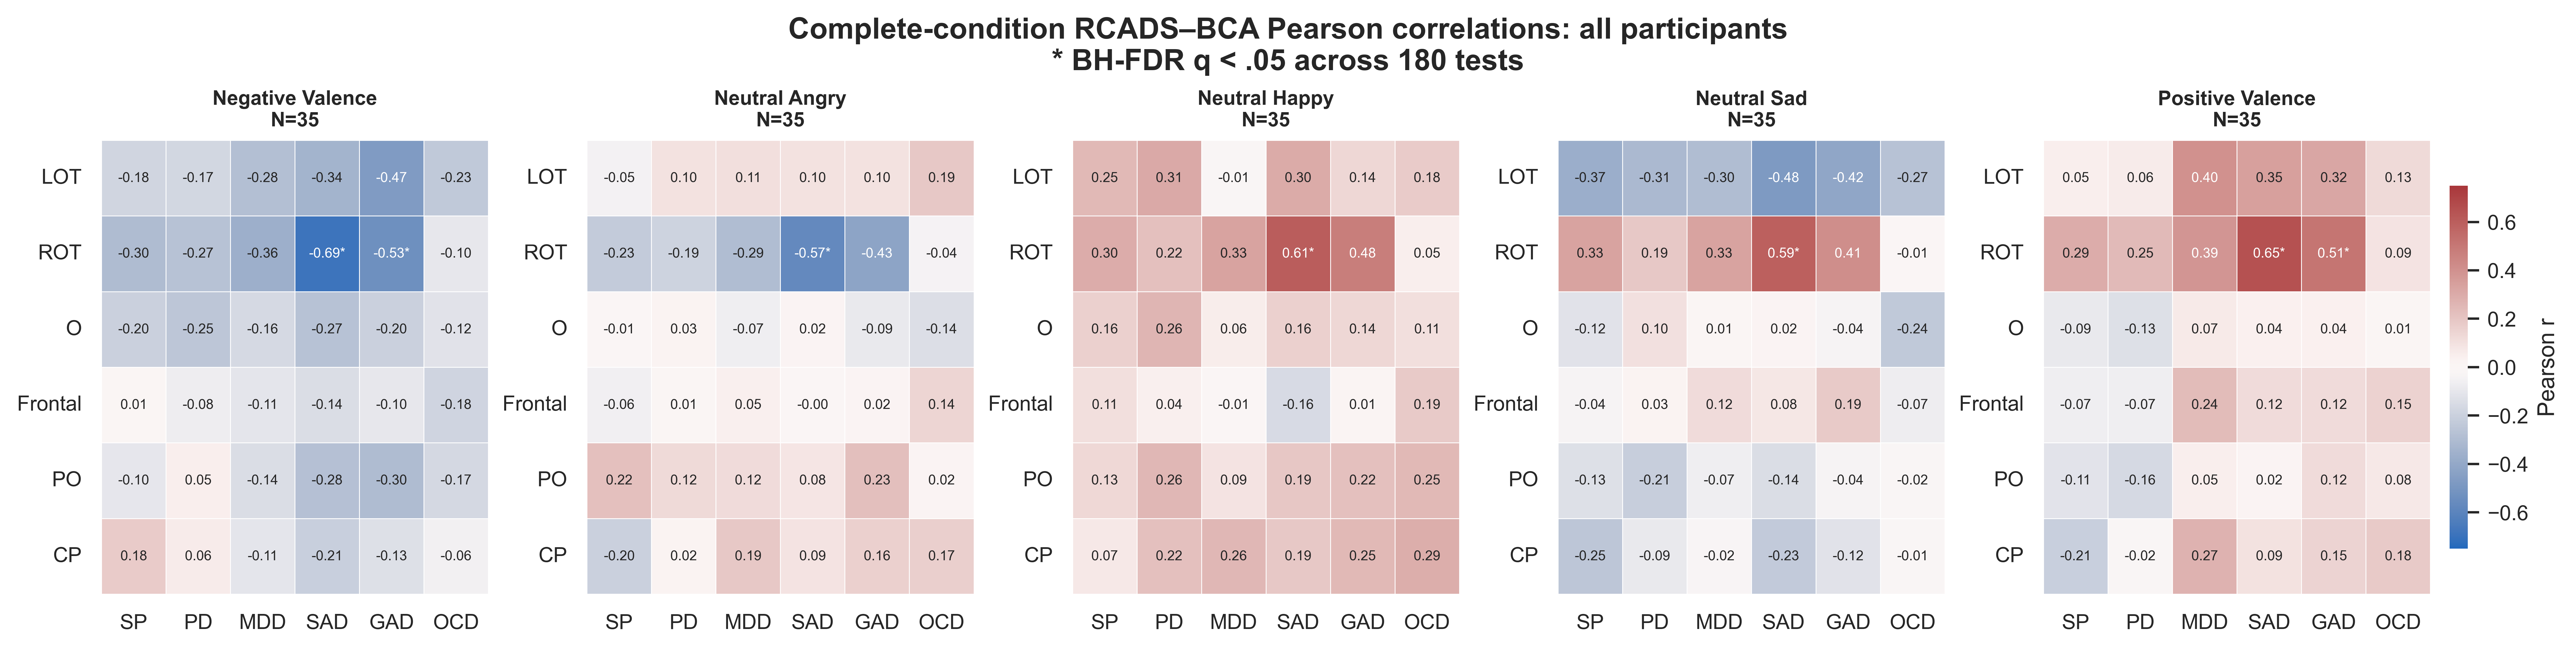

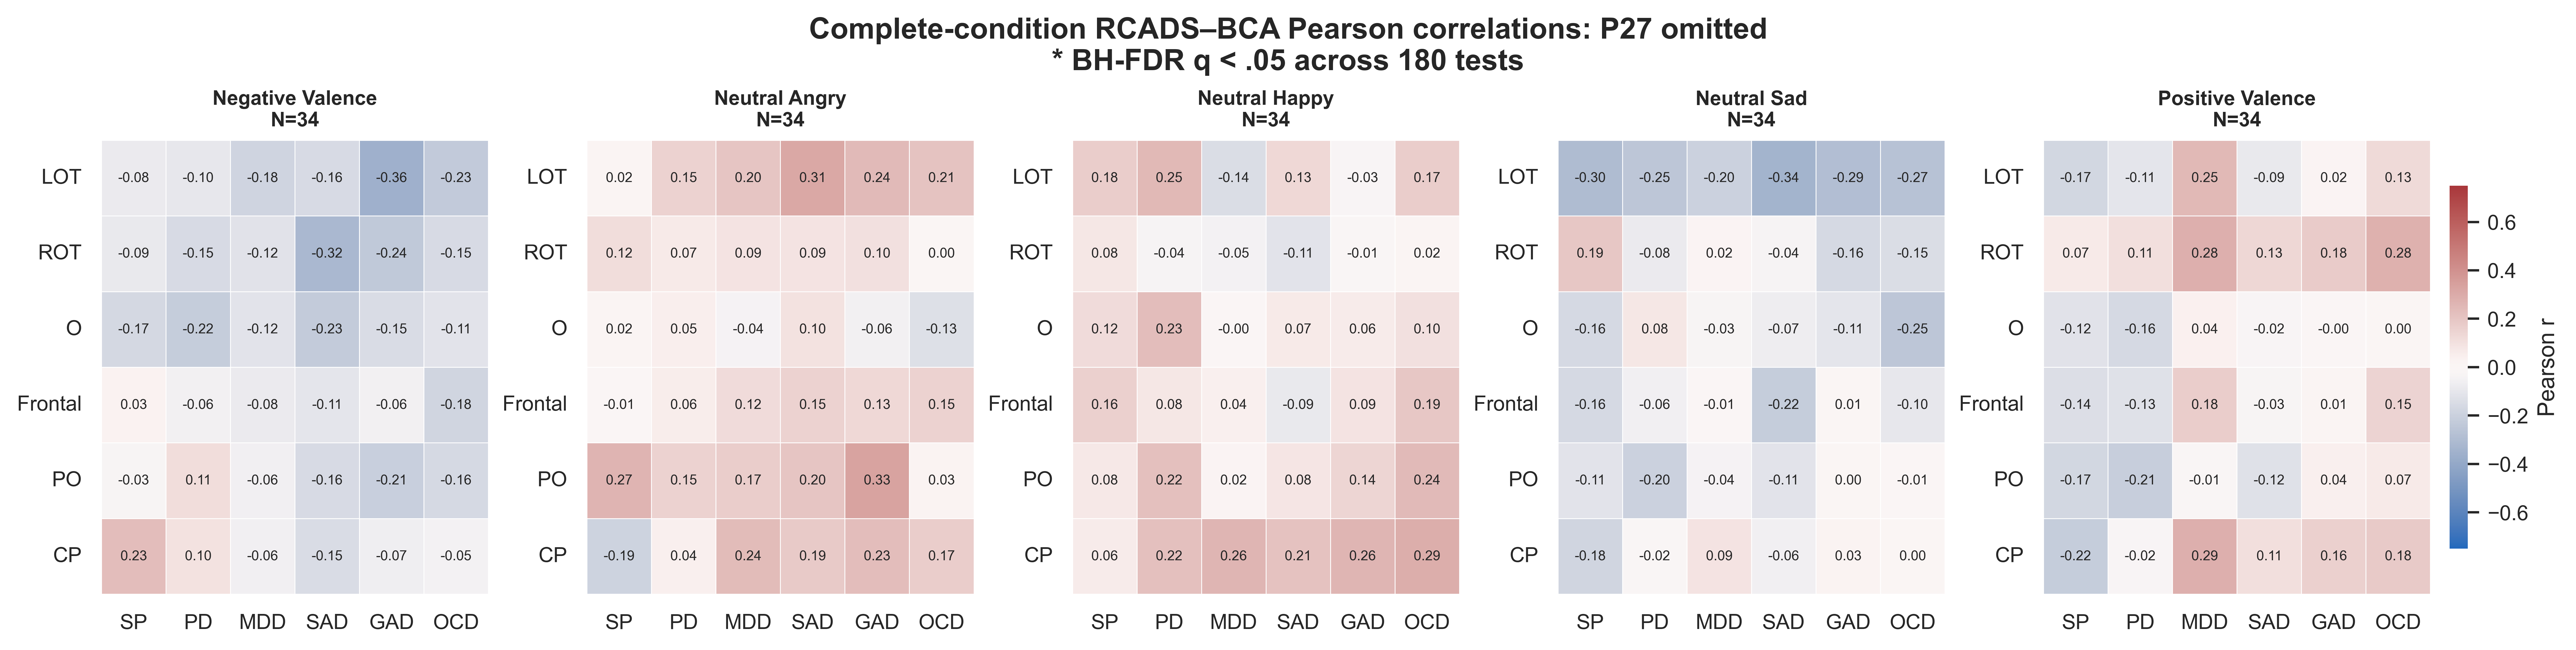

In [4]:
display(Image(filename=str(OUTPUT_DIR / "complete_condition_heatmap_all.png"), width=1100))
display(Image(filename=str(OUTPUT_DIR / "complete_condition_heatmap_without_P27.png"), width=1100))

With all 35 participants, seven of 180 Pearson tests survived BH-FDR correction, all in ROT. Five involved Separation Anxiety and two involved Generalized Anxiety. The condition-specific mixed-model screen yielded 14 of 30 BH-corrected score-by-ROI omnibus findings. These apparent discoveries were not robust: after omitting P27, the broad Pearson, Spearman, and mixed-model screens all had zero corrected findings. Honoring the workbook QC flags produced the same substantive conclusion because corrected results again fell to zero when P27 was also omitted. T-score and age/sex-adjusted broad results likewise had no corrected findings after P27 omission.

## Focused post-hoc amplitude analysis

In [5]:
focused_amp = pd.read_csv(OUTPUT_DIR / "focused_amplitude_lmms.csv")
display(
    focused_amp.loc[
        focused_amp["Effect"].eq("Any score-related amplitude association"),
        [
            "Variant", "RCADS Scale", "N Participants",
            "Likelihood-Ratio Chi-Square", "Degrees of Freedom", "p",
            "Focused Amplitude LMM p (Holm)",
        ],
    ].round(4)
)
focused_cells = pd.read_csv(OUTPUT_DIR / "focused_amplitude_correlations.csv")
rank_hits = focused_cells.loc[
    focused_cells["Spearman q (BH-FDR)"].lt(.06),
    ["Variant", "Condition", "ROI", "RCADS Scale", "Pearson r", "Spearman rho", "Spearman p", "Spearman q (BH-FDR)"],
]
display(rank_hits.round(4))

,Variant,RCADS Scale,N Participants,Likelihood-Ratio Chi-Square,Degrees of Freedom,p,Focused Amplitude LMM p (Holm)
0,All 35 participants; focused post-hoc,Social Phobia,35,31.4772,12,0.0017,0.0033
3,All 35 participants; focused post-hoc,Panic Disorder,35,20.3642,12,0.0605,0.0605
6,P27 omitted; focused post-hoc,Social Phobia,34,8.4320,12,0.7505,0.7505
9,P27 omitted; focused post-hoc,Panic Disorder,34,16.5984,12,0.1653,0.3307


,Variant,Condition,ROI,RCADS Scale,Pearson r,Spearman rho,Spearman p,Spearman q (BH-FDR)
11,All 35 participants; focused post-hoc,Neutral Happy,CP,Panic Disorder,0.2220,0.5034,0.0021,0.0493
35,P27 omitted; focused post-hoc,Neutral Happy,CP,Panic Disorder,0.2191,0.5056,0.0023,0.0548


The all-participant amplitude LMM found an overall Social Phobia association across the Happy/Sad × ROI response surface, but this disappeared after P27 was omitted. Panic was not significant. At the individual ROI level, no Pearson correlation survived the 24-test correction. A Neutral Happy CP–Panic Spearman association was borderline and nearly identical with and without P27, but it had a weak Pearson coefficient and narrowly missed BH-FDR after P27 omission. This is a possible monotonic trend, not reliable evidence of a linear BCA association.

## Focused post-hoc lateralization analysis

In [6]:
focused_lat = pd.read_csv(OUTPUT_DIR / "focused_lateralization_correlations.csv")
display(
    focused_lat[
        [
            "Variant", "Condition", "RCADS Scale", "N", "Pearson r",
            "Pearson CI 95% Low", "Pearson CI 95% High", "Pearson p",
            "Pearson p (Holm)", "Spearman rho", "Spearman p",
            "Spearman p (Holm)",
        ]
    ].round(4)
)

,Variant,Condition,RCADS Scale,N,Pearson r,Pearson CI 95% Low,Pearson CI 95% High,Pearson p,Pearson p (Holm),Spearman rho,Spearman p,Spearman p (Holm)
0,All 35 participants; focused lateralization,Neutral Happy,Social Phobia,35,0.2707,-0.0688,0.5540,0.1158,0.3208,0.0303,0.8627,1.0000
1,All 35 participants; focused lateralization,Neutral Happy,Panic Disorder,35,0.1773,-0.1657,0.4821,0.3082,0.3208,-0.1007,0.5648,1.0000
2,All 35 participants; focused lateralization,Neutral Sad,Social Phobia,35,0.4230,0.1045,0.6628,0.0113,0.0454,0.5044,0.0020,0.0080
3,All 35 participants; focused lateralization,Neutral Sad,Panic Disorder,35,0.2772,-0.0617,0.5588,0.1069,0.3208,0.2036,0.2408,0.7223
4,P27 omitted; focused lateralization,Neutral Happy,Social Phobia,34,-0.0635,-0.3933,0.2807,0.7211,0.7211,-0.0478,0.7883,0.9406
5,P27 omitted; focused lateralization,Neutral Happy,Panic Disorder,34,-0.2851,-0.5684,0.0588,0.1022,0.3066,-0.1781,0.3135,0.9406
6,P27 omitted; focused lateralization,Neutral Sad,Social Phobia,34,0.4533,0.1360,0.6863,0.0071,0.0284,0.4656,0.0055,0.0221
7,P27 omitted; focused lateralization,Neutral Sad,Panic Disorder,34,0.1741,-0.1743,0.4838,0.3247,0.6495,0.1480,0.4035,0.9406


,Variant,RCADS Scale,Effect,Likelihood-Ratio Chi-Square,Degrees of Freedom,p,Focused Lateralization LMM p (Holm)
0,All 35 participants; focused lateralization,Social Phobia,Average score slope across conditions,4.0733,1,0.0436,0.1743
1,All 35 participants; focused lateralization,Social Phobia,Condition x score interaction,0.1200,1,0.7290,1.0000
2,All 35 participants; focused lateralization,Panic Disorder,Average score slope across conditions,1.6908,1,0.1935,0.5805
3,All 35 participants; focused lateralization,Panic Disorder,Condition x score interaction,0.0512,1,0.8210,1.0000
4,P27 omitted; focused lateralization,Social Phobia,Average score slope across conditions,2.6704,1,0.1022,0.2045
5,P27 omitted; focused lateralization,Social Phobia,Condition x score interaction,6.2830,1,0.0122,0.0488
6,P27 omitted; focused lateralization,Panic Disorder,Average score slope across conditions,0.1118,1,0.7381,0.7381
7,P27 omitted; focused lateralization,Panic Disorder,Condition x score interaction,4.3519,1,0.0370,0.1109


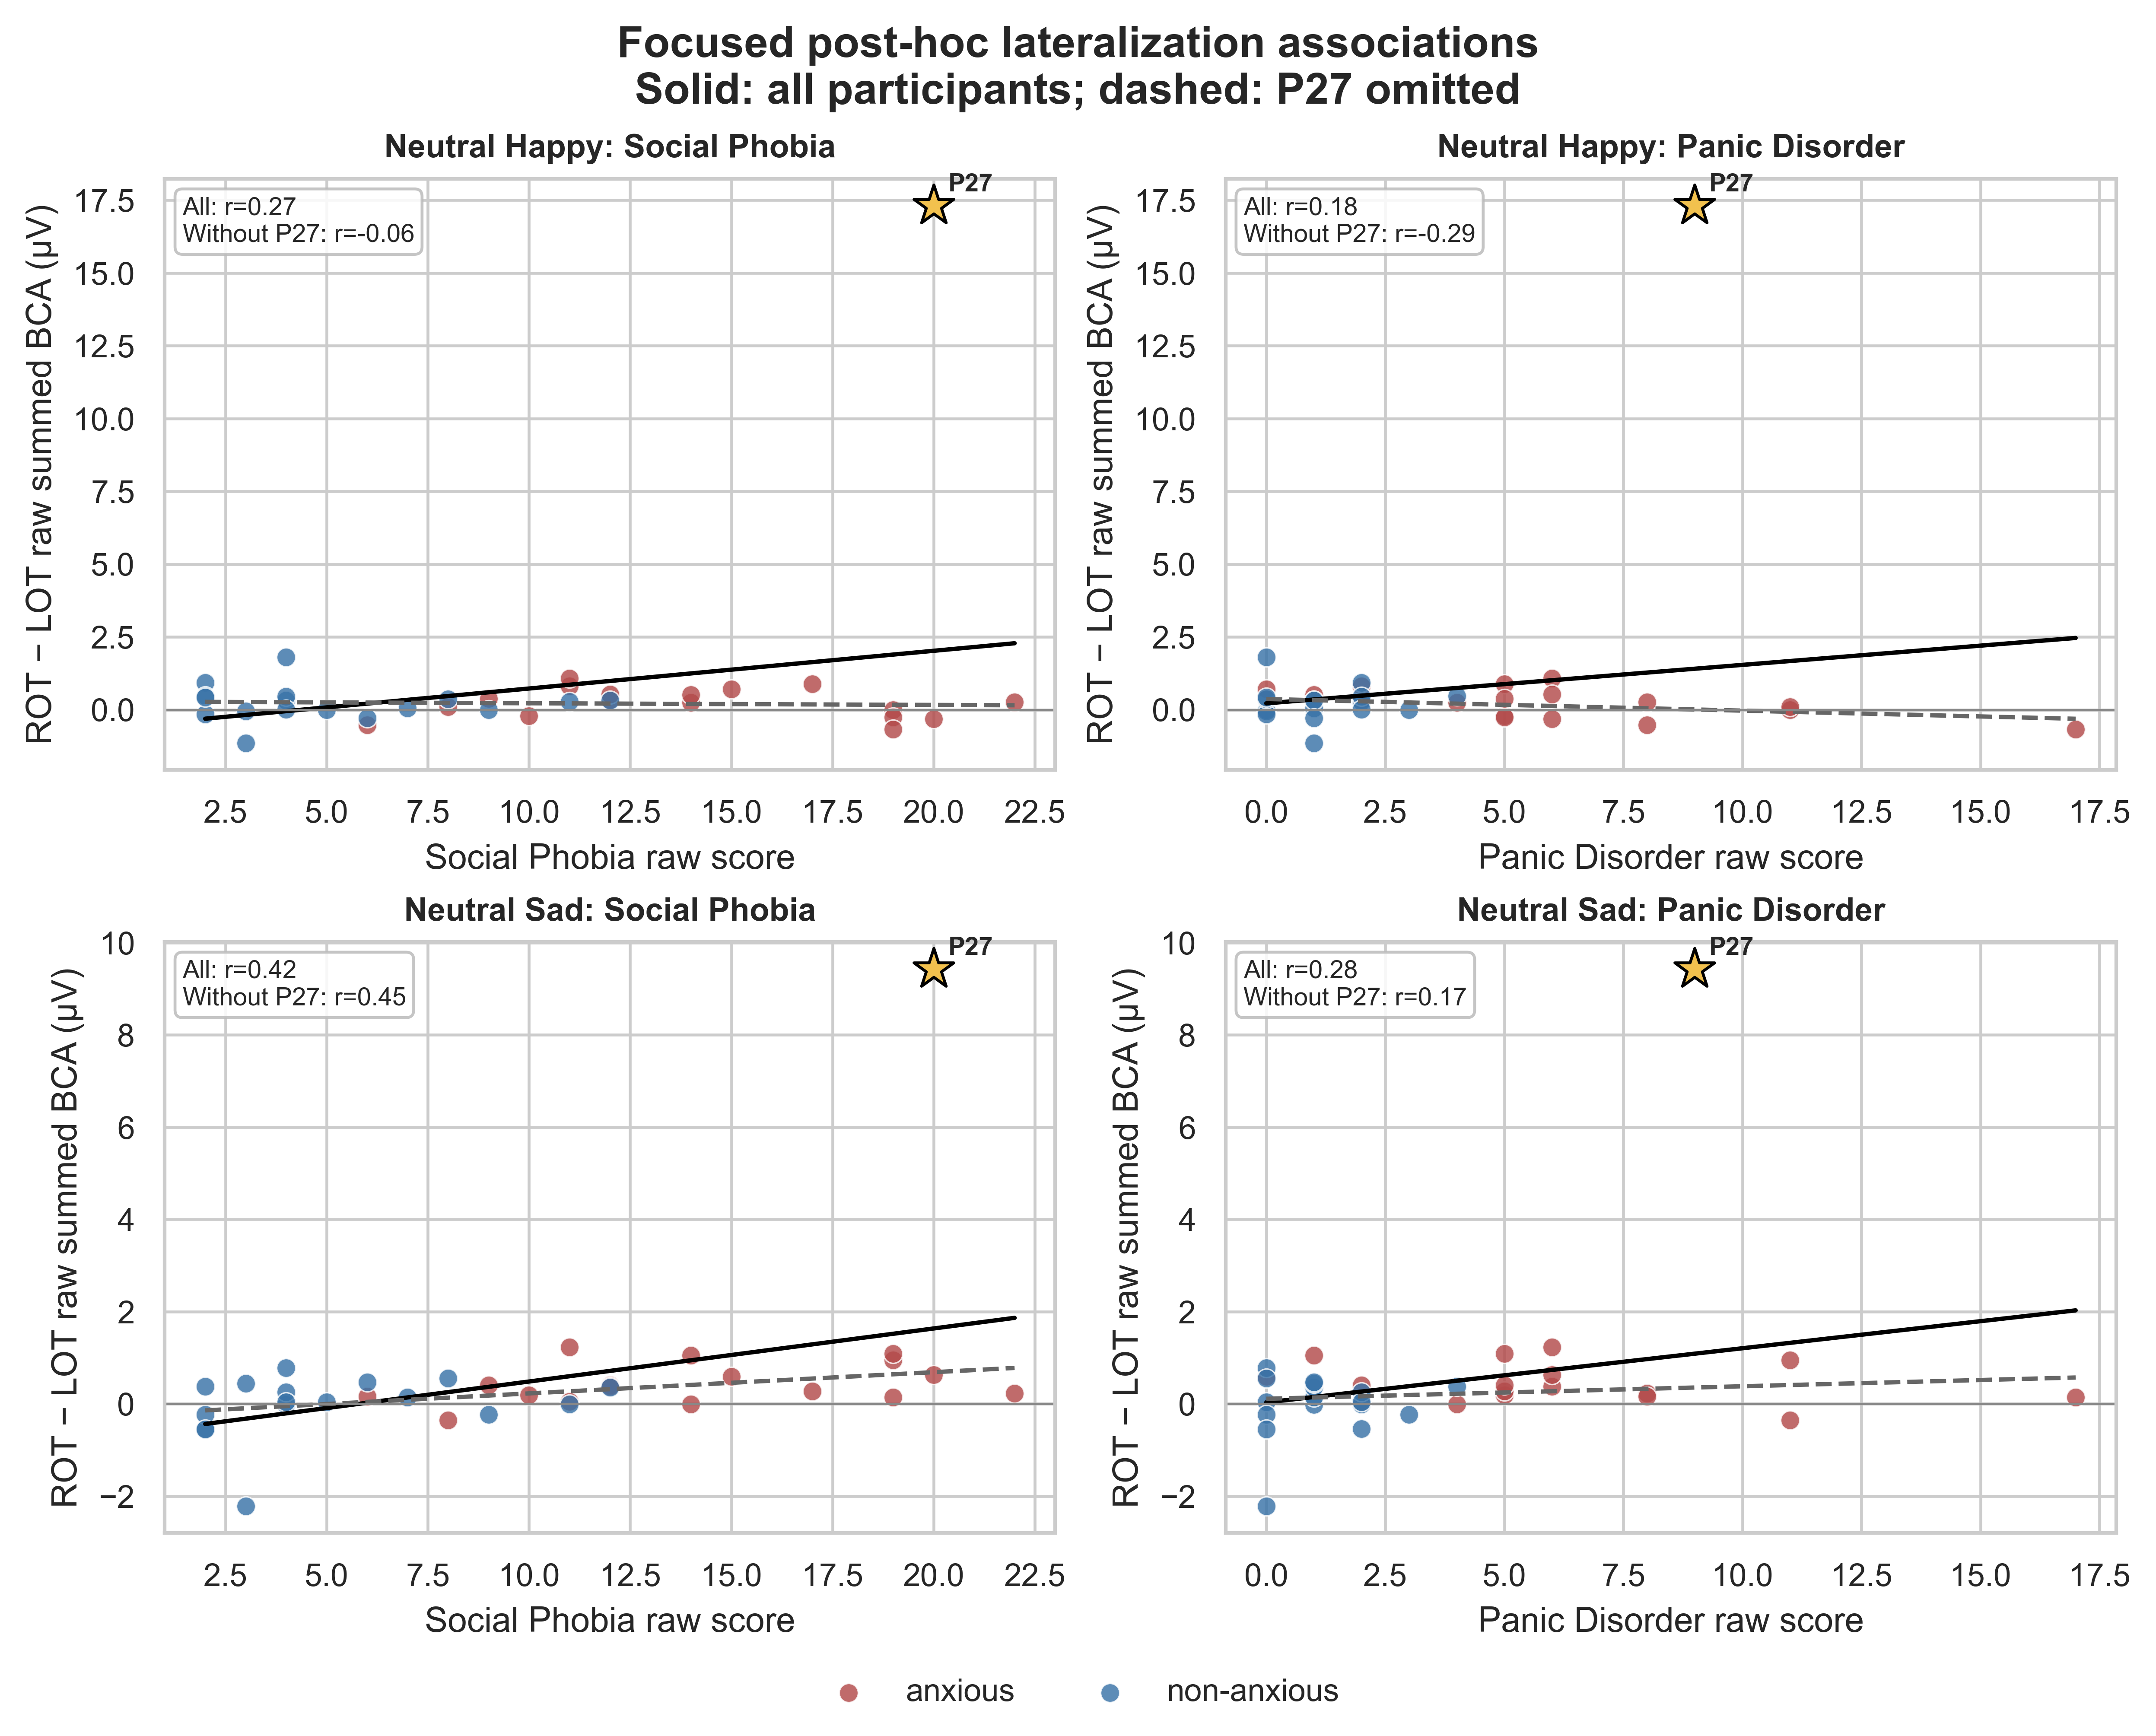

In [7]:
focused_models = pd.read_csv(OUTPUT_DIR / "focused_lateralization_lmms.csv")
display(
    focused_models[
        [
            "Variant", "RCADS Scale", "Effect",
            "Likelihood-Ratio Chi-Square", "Degrees of Freedom", "p",
            "Focused Lateralization LMM p (Holm)",
        ]
    ].round(4)
)
display(Image(filename=str(OUTPUT_DIR / "focused_lateralization.png"), width=850))

Neutral Sad lateralization showed the clearest stable result. Higher Social Phobia raw scores were associated with a more positive ROT − LOT value with all participants, Pearson `r = .423`, Holm-adjusted `p = .045`, and Spearman `rho = .504`, Holm-adjusted `p = .008`. Omitting P27 slightly strengthened the Pearson association, `r = .453`, adjusted `p = .028`, while the rank association remained similar, `rho = .466`, adjusted `p = .022`. The other three focused correlations were not significant.

This is not the same as proving Sad specificity. In a direct repeated-measures model, the Social Phobia slope did not differ between Neutral Sad and Neutral Happy when P27 was included. The interaction became significant only after P27 was omitted. P27 had unusually large positive lateralization in both Happy and Sad, so including P27 made the two conditions look more alike. Accordingly, the within-Sad association is stable to P27 handling, whereas the claim that Sad is uniquely stronger than Happy is not.

## Demographic and norm-score sensitivities

In [8]:
partial = pd.read_csv(OUTPUT_DIR / "focused_lateralization_partial_age_sex.csv")
t_scores = pd.read_csv(OUTPUT_DIR / "focused_lateralization_t_scores.csv")
display(
    partial.loc[
        partial["Condition"].eq("Neutral Sad") & partial["RCADS Scale"].eq("Social Phobia"),
        ["Variant", "N", "Partial Pearson r", "Partial Pearson p", "Partial Pearson p (Holm)"],
    ].round(4)
)
display(
    t_scores.loc[
        t_scores["Condition"].eq("Neutral Sad") & t_scores["RCADS Scale"].eq("Social Phobia"),
        ["Variant", "N", "Pearson r", "Pearson p (Holm)", "Spearman rho", "Spearman p (Holm)"],
    ].round(4)
)

,Variant,N,Partial Pearson r,Partial Pearson p,Partial Pearson p (Holm)
2,All 35 participants; focused lateralization,35,0.3599,0.0396,0.1586
6,P27 omitted; focused lateralization,34,0.4086,0.0202,0.0810


,Variant,N,Pearson r,Pearson p (Holm),Spearman rho,Spearman p (Holm)
2,All 35 participants; focused lateralization T ...,35,0.4029,0.0657,0.4852,0.0125
6,P27 omitted; focused lateralization T scores,34,0.4420,0.0355,0.4447,0.0336


Age/sex adjustment reduced precision: the Neutral Sad Social Phobia partial correlations remained positive and moderate, but did not survive Holm correction. This is important because sex is imbalanced across the anxiety-defined groups and is strongly related to RCADS norms. The T-score sensitivity retained the same positive pattern; the Spearman association survived focused correction both with and without P27, while Pearson survived only without P27. Raw and T scores are transformations of the same responses and should not be counted as independent confirmation.

## Overall interpretation

There is no robust evidence here that RCADS severity tracks absolute BCA amplitude across the complete condition × ROI grid. The broad corrected amplitude findings are driven by one influential participant. The most credible hypothesis-generating result is narrower: participants with higher Social Phobia scores tended to show greater right-than-left occipito-temporal BCA during Neutral Sad, and that within-condition relationship did not depend on P27. Because the variables were selected after reviewing a larger screen, this remains post hoc even after focused multiplicity correction. It warrants preregistered replication, but should not yet be presented as a validated biomarker or as conclusive evidence that the relationship is specific to sad faces.